In [1]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [9]:
using Revise
includet("./base.jl")

In [15]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

# Generate systems, solve ODE, filter and test

In [38]:
K = 10.
l = 0.999
T = 1e8
tol = 1e-9
df = solve_si_odes("test1.jld2", 50,
    K, l,
    T, tol,
);
count(df.good), nrow(df)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:24

(32, 50)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00

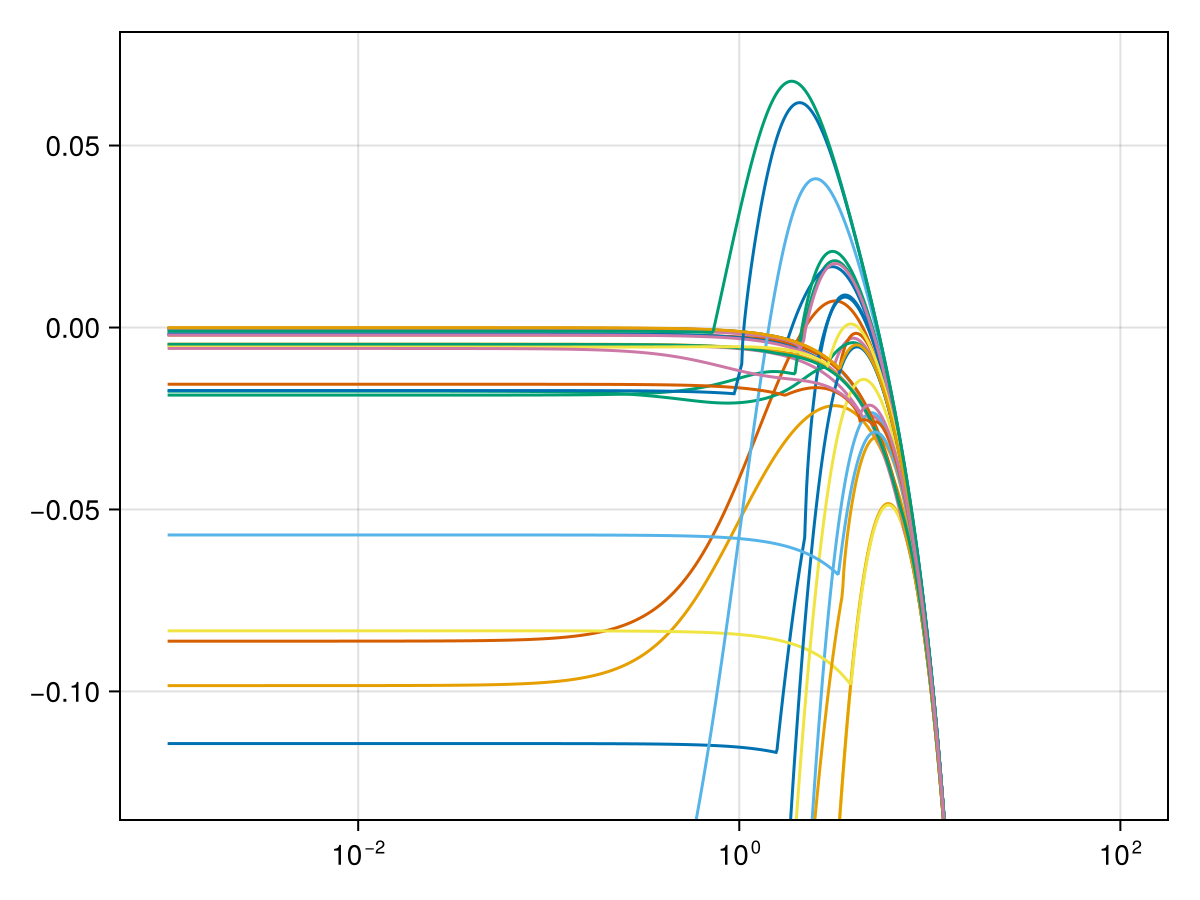

In [39]:
ks = 10 .^ range(-3, 2, 1000)
DN = 1e-3
p = 1e0
(; Ds, mrls) = si_disprels(df, ks, DN, 1., p);

fig = Figure()
ax = Axis(fig[1,1]; xscale=log10)

for i in 1:nrow(df)
    if df.good[i]
        lines!(ks, mrls[i])
    end
end

mm = abs(maximum(maximum.(mrls[df.good])))
# xlims!(ax, 1e0, 1e2)
ylims!(ax, (-2., 1.2) .* mm)

fig

# Disprels ps, find a sensible system size and prep for PDE runs

In [51]:
num_systems = 10

# disprels and peak finding
ks = 10 .^ range(-4, 3, 2000)  # grid the peak k gets read off, no root finding
ps = 10 .^ range(-2, 0, 5)          # byproduct diffusions (DR) to compare each system at
DN = 1e-3                      # strain diffusion
DI = 1.0                       # influx resource diffusion

# system size and spatial u0
start_peaks = 100  # peaks the domain fits at the *smallest* p, this sets L
sN = 2500        # spatial gridpoints, same for every system so dx varies with L
epsilon = 1e-3   # uniform +/- perturbation added to the ODE steady state
seed = 1         # so the u0s can be regenerated
T = T          # PDE end time, same as the ODE T in the section above

out_fname = "main2_panel_e/systems.jld2"

"main2_panel_e/systems.jld2"

In [45]:
gdf = df[df.good, :]
gdf.df_row = findall(df.good) # which df row each one was, survives later filtering

(; mrls, peak_ks, peak_hs, at_edge) = disprel_peak_ks(gdf, ks, DN, DI, ps)

# peaks on the edge of the ks range are not real peaks - widen ks if any turn up
count(at_edge), count(ismissing, peak_ks), length(peak_ks)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00

(0, 69, 160)

In [46]:
# Drop anything that is not spatially unstable at *every* p. `good` only says the
# well-mixed steady state is stable (that is the k=0 Jacobian), so a good system
# can still have no k>0 instability, and then there is no peak to size a domain
# to. Cutting them here means nothing downstream has to deal with missings.
keep = findall([all(!ismissing, peak_ks[i, :]) for i in 1:nrow(gdf)])
@show length(keep), nrow(gdf)
if !isnothing(num_systems)
    keep = keep[sample(1:length(keep), num_systems; replace=false)]
end;

gdf = gdf[keep, :]
mrls = mrls[keep, :]
peak_ks = disallowmissing(peak_ks[keep, :])
peak_hs = disallowmissing(peak_hs[keep, :])
at_edge = at_edge[keep, :]
nrow(gdf)

(length(keep), nrow(gdf)) = (11, 32)

10

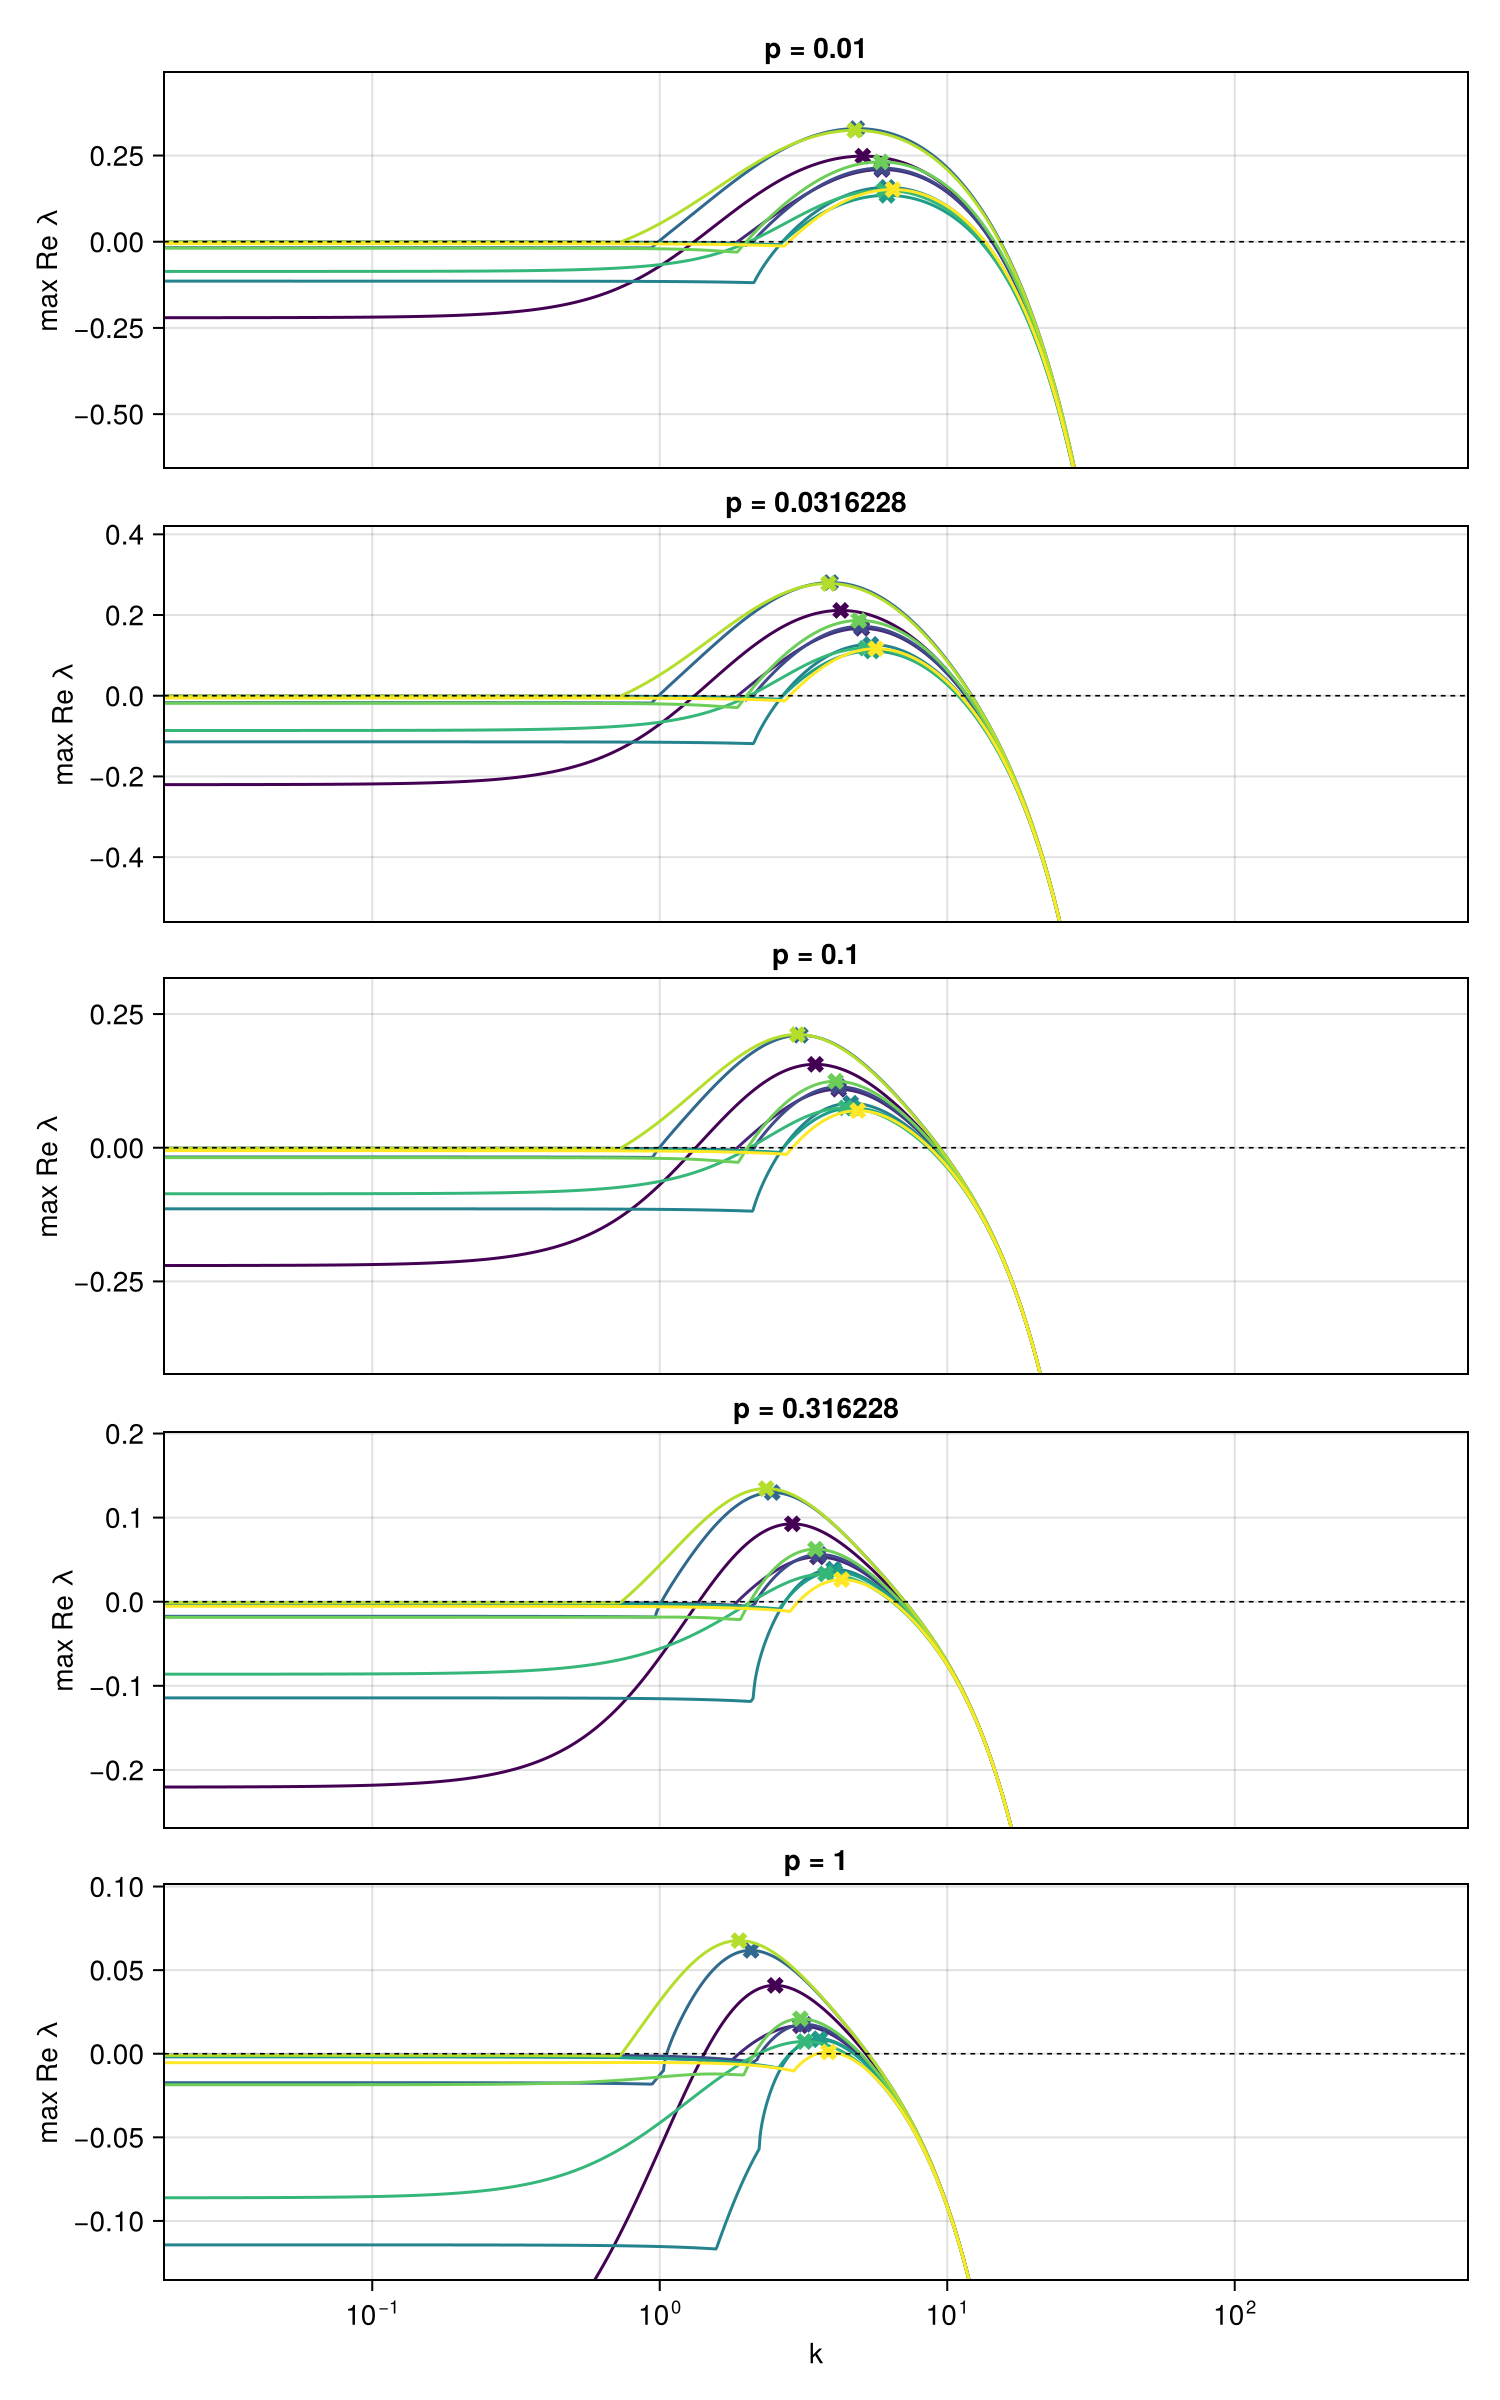

In [47]:
colors = Makie.resample_cmap(:viridis, max(nrow(gdf), 2))

fig = Figure(; size=(750, 240 * length(ps)))
axs = map(eachindex(ps)) do j
    Axis(fig[j, 1]; xscale=log10, ylabel="max Re λ", title=@sprintf("p = %g", ps[j]))
end
axs[end].xlabel = "k"

for j in eachindex(ps)
    for i in 1:nrow(gdf)
        lines!(axs[j], ks, mrls[i, j]; color=colors[i])
        scatter!(axs[j], [peak_ks[i, j]], [peak_hs[i, j]];
            color=colors[i], marker=:xcross, markersize=12)
    end
    hlines!(axs[j], 0.0; color=:black, linestyle=:dash, linewidth=0.8)
    mm = maximum(peak_hs[:, j]) # scale each panel by its own tallest peak
    ylims!(axs[j], -2mm, 1.5mm)
end

linkxaxes!(axs...)
# zoom onto where the peaks actually are rather than the whole scanned range
pkext = extrema(peak_ks)
# on all of them, not just the linked one - an axis left on autolimits pulls the
# whole link back out to the full ks range
xlims!.(axs, pkext[1] / 100, pkext[2] * 100)
hidexdecorations!.(axs[1:end-1]; grid=false)
rowgap!(fig.layout, 8)

fig

In [48]:
# One L per system, fixed by its peak k at the *smallest* p, so that run starts
# with exactly start_peaks peaks. Unlike choose_Ls, which sizes off the smallest
# peak k over all the ps and so only guarantees a floor, this pins the count at
# one chosen p; the other ps get whatever their own peak k gives in that L, which
# here is fewer, since peak k falls as p rises.
jL = argmin(ps)
Ls = choose_L.(peak_ks[:, jL], start_peaks)

sizes_df = DataFrame(; df_row=gdf.df_row, L=Ls)
for j in eachindex(ps)
    sizes_df[!, @sprintf("k_p%g", ps[j])] = peak_ks[:, j]
    # what the chosen L actually buys at this p - start_peaks at ps[jL]
    sizes_df[!, @sprintf("n_p%g", ps[j])] = num_peaks_in.(Ls, peak_ks[:, j])
end
sizes_df

Row,df_row,L,k_p0.01,n_p0.01,k_p0.0316228,n_p0.0316228,k_p0.1,n_p0.1,k_p0.316228,n_p0.316228,k_p1,n_p1
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,33,123.545,5.08573,100.0,4.25907,83.7455,3.48154,68.457,2.89222,56.8692,2.52174,49.5847
2,15,105.997,5.9277,100.0,5.04489,85.1069,4.19094,70.7009,3.53813,59.6881,3.08493,52.0425
3,40,105.997,5.9277,100.0,5.00437,84.4235,4.19094,70.7009,3.59565,60.6585,3.18604,53.7484
4,44,129.669,4.84555,100.0,3.92914,81.0876,3.08493,63.6652,2.46148,50.7987,2.07806,42.8861
5,1,101.809,6.17156,100.0,5.42459,87.8966,4.61671,74.8061,4.02534,65.224,3.59565,58.2616
6,28,101.809,6.17156,100.0,5.46851,88.6082,4.69176,76.0222,4.05793,65.752,3.59565,58.2616
7,13,104.301,6.02407,100.0,5.21025,86.4905,4.43428,73.6094,3.77388,62.6467,3.18604,52.8886
8,18,106.855,5.8801,100.0,4.92432,83.7455,4.09078,69.5699,3.48154,59.2088,3.08493,52.4638
9,48,131.777,4.76803,100.0,3.86628,81.0876,3.0112,63.1539,2.34523,49.1865,1.88642,39.5639


In [49]:
Random.seed!(seed)

# One u0 per system, shared by all of its p runs: the p comparison should not be
# confounded by each run starting from a different random perturbation. sN is
# fixed so dx = L/sN varies between systems, but since L was picked to fit a set
# number of peaks that means a fixed resolution *per peak*, which is what matters.
u0s = map(1:nrow(gdf)) do i
    Ns, Nr = get_Ns(gdf.params[i])
    u0 = perturb_u0_uniform(Ns, Nr, expand_u0_to_size((sN,), gdf.final_states[i]), epsilon)
    clamp.(u0, 0., Inf)
end

@show length(u0s) size(u0s[1])
extrema(Ls ./ sN) # dx range

length(u0s) = 10
size(u0s[1]) = (40, 2500)

(0.03880021720836258, 0.05271093138213548)

In [52]:
# One row per (system, p) - everything a PDE run needs bar the tolerances and
# maxtime, which are left to whoever runs it.
sysjs = [(i, j) for i in 1:nrow(gdf) for j in eachindex(ps)]

pde_df = DataFrame(;
    gdf_row=[i for (i, _) in sysjs],             # index into gdf / u0s
    df_row=[gdf.df_row[i] for (i, _) in sysjs],  # index into the original df
    p=[ps[j] for (_, j) in sysjs],
    params=[gdf.params[i] for (i, _) in sysjs],
    Ds=[make_si_Ds(gdf.params[i], DN, DI, ps[j]) for (i, j) in sysjs],
    L=[Ls[i] for (i, _) in sysjs],
    sN=fill(sN, length(sysjs)),
    T=fill(T, length(sysjs)),
    u0=[u0s[i] for (i, _) in sysjs],  # same array object across a system's ps
    mrls=[mrls[i, j] for (i, j) in sysjs],  # disprel on metadata.ks, handy to look at
)

metadata = (; K, l, ks, ps, DN, DI, start_peaks, sN, epsilon, seed)
jldsave(out_fname; metadata, pde_df)

@show nrow(pde_df) filesize(out_fname) / 1e6
select(pde_df, Not(:params, :Ds, :u0, :mrls)) # the big columns just spam the output

nrow(pde_df) = 50
filesize(out_fname) / 1.0e6 = 9.589457

Row,gdf_row,df_row,p,L,sN,T
,Int64,Int64,Float64,Float64,Int64,Float64
1,1,33,0.01,123.545,2500,1.0e8
2,1,33,0.0316228,123.545,2500,1.0e8
3,1,33,0.1,123.545,2500,1.0e8
4,1,33,0.316228,123.545,2500,1.0e8
5,1,33,1.0,123.545,2500,1.0e8
6,2,15,0.01,105.997,2500,1.0e8
7,2,15,0.0316228,105.997,2500,1.0e8
8,2,15,0.1,105.997,2500,1.0e8
9,2,15,0.316228,105.997,2500,1.0e8
